# Micro Financial Loan - Predictive Model Development

> **Original source:** [cbtham/micro-financial-loan](https://github.com/cbtham/micro-financial-loan)
> **Author:** cbtham
> **Adapted by:** [gymnatics/openshift-installation](https://github.com/gymnatics/openshift-installation) for dynamic cluster configuration

In [ ]:
# Auto-configure environment for this cluster
# Override any value by creating a .env file in this directory

import os
try:
    from dotenv import load_dotenv
    load_dotenv(os.path.join(os.path.dirname(os.path.abspath("__file__")), ".env"), override=True)
except ImportError:
    pass

S3_ENDPOINT = os.environ.get("S3_ENDPOINT", "http://minio.financial-loan-demo.svc:9000")
AWS_ACCESS_KEY_ID = os.environ.get("AWS_ACCESS_KEY_ID", "minio")
AWS_SECRET_ACCESS_KEY = os.environ.get("AWS_SECRET_ACCESS_KEY", "minio123")
S3_BUCKET_DATA = os.environ.get("S3_BUCKET_DATA", "datasets")
S3_BUCKET_MODELS = os.environ.get("S3_BUCKET_MODELS", "models")
NAMESPACE = os.environ.get("NAMESPACE", "financial-loan-demo")

print("=" * 60)
print("Environment Configuration")
print("=" * 60)
print(f"  S3 Endpoint:    {S3_ENDPOINT}")
print(f"  Data Bucket:    {S3_BUCKET_DATA}")
print(f"  Models Bucket:  {S3_BUCKET_MODELS}")
print(f"  Namespace:      {NAMESPACE}")
print("=" * 60)
print("To override, create a .env file or set environment variables")

# Micro Financial Loan Model Development
**OBJECTIVE:** Train a robust XGBoost model compatible with KServe/MLServer API deployment.

**Full Pipeline:** Data download -> Preprocessing -> Training -> Upload


## 1. Install Dependencies

In [1]:
!pip install -q xgboost scikit-learn joblib seaborn


[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


## 2. Setup Workbench Environment & Download Data Set

In [ ]:
import boto3
from botocore.client import Config
import urllib3
import os
import sys
import subprocess

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

# Install missing packages if needed
try:
    import shap
except ImportError:
    print("Installing SHAP for model explanations...")
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'shap'])
    import shap

# MinIO Configuration
s3 = boto3.client(
    's3',
    endpoint_url=S3_ENDPOINT,
    aws_access_key_id=AWS_ACCESS_KEY_ID,
    aws_secret_access_key=AWS_SECRET_ACCESS_KEY,
    config=Config(signature_version='s3v4'),
    verify=False
)

# Create data directory
if not os.path.exists("data"):
    os.makedirs("data")

print("Downloading training data from MinIO...")
print("="*60)

# Download from datasets bucket
try:
    s3.download_file('datasets', 'microloan-dataset/application_train.csv', 'data/application_train.csv')
    size = os.path.getsize('data/application_train.csv') / (1024*1024)
    print(f"✓ Downloaded application_train.csv: {size:.1f} MB")
except Exception as e:
    print(f"✗ Download failed: {e}")
    print("Please ensure the dataset is in MinIO bucket 'datasets' path 'microloan-dataset/application_train.csv'")


✓ Downloaded application_train.csv: 158.4 MB


## 3. Load Libraries

In [ ]:
import pandas as pd
import numpy as np
import joblib
import json
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve

from xgboost import XGBClassifier
import xgboost
import sklearn

print(f"✓ Libraries loaded successfully")
print(f"  - XGBoost: {xgboost.__version__}")
print(f"  - SHAP: {shap.__version__}")


✓ Libraries loaded successfully
  - XGBoost: 3.1.3
  - SHAP: 0.50.0


## 4. Review Data Set

✓ Dataset loaded: 307,511 rows, 122 columns
DATA STORY: Understanding the Loan Portfolio


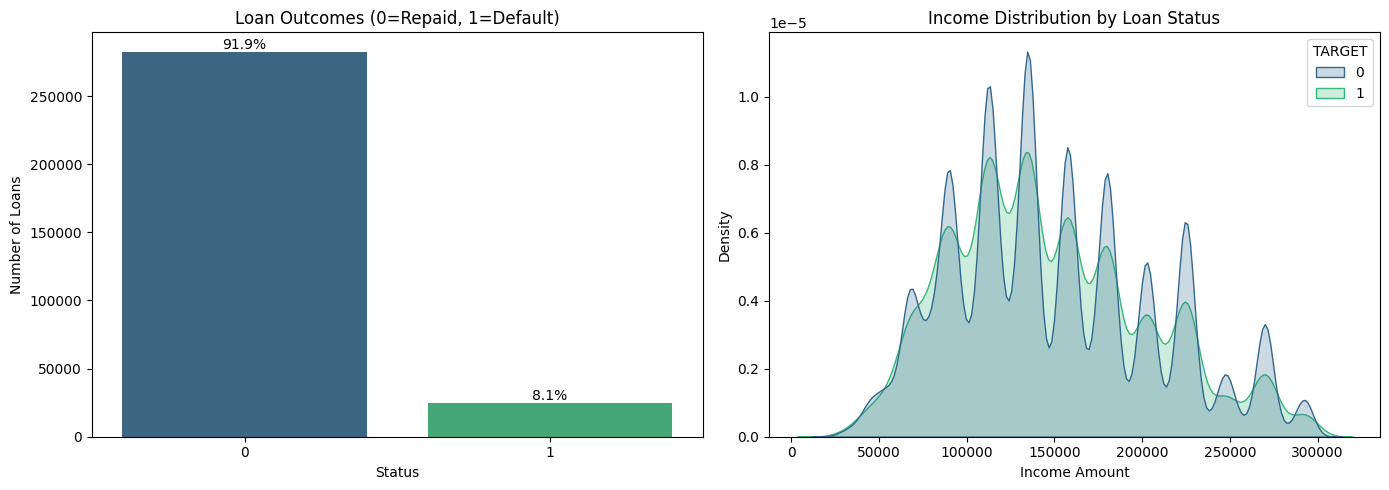

Observation: The dataset is imbalanced (~92% Repaid vs ~8% Default).
We will use class weighting to handle this imbalance during training.


In [ ]:
if os.path.exists('data/application_train.csv'):
    df = pd.read_csv('data/application_train.csv')
    print(f"✓ Dataset loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")
    
    # DATA STORY VISUALIZATION
    print("" + "="*60)
    print("DATA STORY: Understanding the Loan Portfolio")
    print("="*60)
    
    plt.figure(figsize=(14, 5))
    
    # 1. Class Balance
    plt.subplot(1, 2, 1)
    ax = sns.countplot(x='TARGET', data=df, palette='viridis')
    plt.title('Loan Outcomes (0=Repaid, 1=Default)')
    plt.xlabel('Status')
    plt.ylabel('Number of Loans')
    # Add percentages
    total = len(df)
    for p in ax.patches:
        percentage = '{:.1f}%'.format(100 * p.get_height()/total)
        x = p.get_x() + p.get_width()/2
        y = p.get_height()
        ax.annotate(percentage, (x, y), ha='center', va='bottom')

    # 2. Income vs Default
    plt.subplot(1, 2, 2)
    # Filter outliers for better visualization
    plot_df = df[df['AMT_INCOME_TOTAL'] < 300000]
    sns.kdeplot(data=plot_df, x='AMT_INCOME_TOTAL', hue='TARGET', fill=True, common_norm=False, palette='viridis')
    plt.title('Income Distribution by Loan Status')
    plt.xlabel('Income Amount')
    
    plt.tight_layout()
    plt.show()
    
    print("Observation: The dataset is imbalanced (~92% Repaid vs ~8% Default).")
    print("We will use class weighting to handle this imbalance during training.")
else:
    print("✗ Data file not found! Please check Step 1.")


## 5. Preprocessing & Feature Engineering

In [ ]:
# Define critical features
numeric_features = [
    'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
    'DAYS_BIRTH', 'DAYS_EMPLOYED', 'REGION_POPULATION_RELATIVE', 'CNT_FAM_MEMBERS'
]
binary_features = ['FLAG_MOBIL', 'FLAG_EMAIL', 'FLAG_WORK_PHONE']
categorical_features = [
    'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS',
    'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE'
]

# Smart imputation (filling missing values)
print("Preprocessing data...")

# 1. Fill income/annuity based on occupation/type groups
df['AMT_INCOME_TOTAL'] = df['AMT_INCOME_TOTAL'].fillna(df.groupby('OCCUPATION_TYPE')['AMT_INCOME_TOTAL'].transform('median'))
df['AMT_ANNUITY'] = df['AMT_ANNUITY'].fillna(df.groupby('NAME_INCOME_TYPE')['AMT_ANNUITY'].transform('median'))
df['AMT_GOODS_PRICE'] = df['AMT_GOODS_PRICE'].fillna(df.groupby(pd.cut(df['AMT_CREDIT'], bins=10))['AMT_GOODS_PRICE'].transform('median'))

# 2. Fill remaining numerics with median
for col in numeric_features:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

# 3. Prepare X and y
X = df[numeric_features + binary_features + categorical_features].copy()
y = df['TARGET']

# 4. One-hot encode
X_encoded = pd.get_dummies(X, columns=categorical_features, drop_first=True)
training_columns = X_encoded.columns.tolist()

# Save column names for later use
joblib.dump(training_columns, 'training_columns.pkl')

print(f"✓ Preprocessing complete. Features: {len(training_columns)}")


Preprocessing data...
✓ Preprocessing complete. Features: 49


## 6. Prepare Data Set for Train and Test

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training Set: {X_train.shape[0]:,} samples")
print(f"Test Set:     {X_test.shape[0]:,} samples")


Training Set: 246,008 samples
Test Set:     61,503 samples


## 7. Model Training

In [ ]:
# Calculate scale_pos_weight for imbalance
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count

print(f"Training with class weighting (scale_pos_weight={scale_pos_weight:.2f})...")

model_pipeline = Pipeline([
    ('preprocessor', ColumnTransformer(
        transformers=[('scaler', StandardScaler(), list(range(len(training_columns))))],
        remainder='passthrough'
    )),
    ('classifier', XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        n_jobs=-1,
        random_state=42
    ))
])

model_pipeline.fit(X_train, y_train)
print("✓ Model trained successfully (API-compatible)")
print(f"  - Uses column indices instead of names")
print(f"  - Compatible with KServe V2 inference protocol")


Training with class weighting (scale_pos_weight=11.39)...
✓ Model trained successfully (API-compatible)
  - Uses column indices instead of names
  - Compatible with KServe V2 inference protocol


## 8. Evaluation

MODEL EXPLANATION & PERFORMANCE
Generating SHAP explanations (this takes ~30s)...


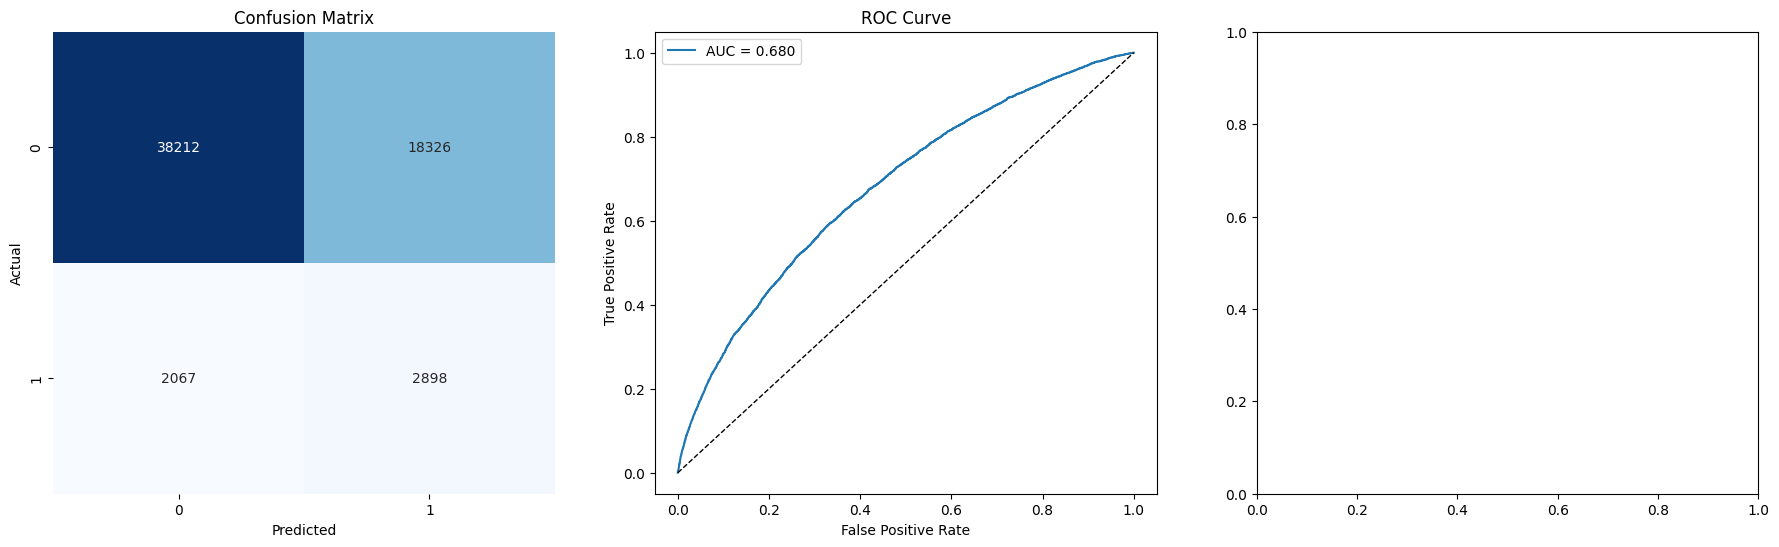

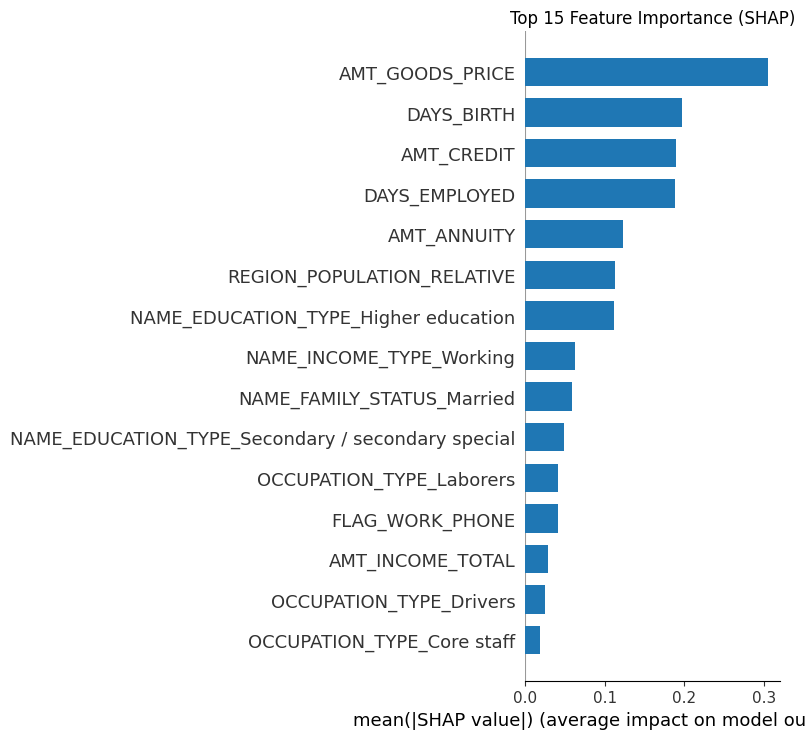

Recall (Sensitivity): 58.37% (Caught Defaults)
ROC AUC Score:        0.6799


In [ ]:
# Predictions
y_pred = model_pipeline.predict(X_test)
y_pred_proba = model_pipeline.predict_proba(X_test)[:, 1]

print("="*60)
print("MODEL EXPLANATION & PERFORMANCE")
print("="*60)

# Wider figure + shared subplots to avoid text overlap
fig, (ax_cm, ax_roc, ax_shap) = plt.subplots(1, 3, figsize=(22, 6))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax_cm, annot_kws={"size": 10})
ax_cm.set_title('Confusion Matrix')
ax_cm.set_xlabel('Predicted')
ax_cm.set_ylabel('Actual')

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
ax_roc.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_pred_proba):.3f}')
ax_roc.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax_roc.set_title('ROC Curve')
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.legend()

# 3. SHAP Summary (Feature Importance)
print("Generating SHAP explanations (this takes ~30s)...")
# Use sample for speed
X_sample = X_test.iloc[:500]
model = model_pipeline.named_steps['classifier']
preprocessor = model_pipeline.named_steps['preprocessor']
X_sample_transformed = preprocessor.transform(X_sample)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample_transformed)

# SHAP Feature Importance
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=training_columns,
    plot_type="bar",
    max_display=15,
    show=False,
    color='#1f77b4'
)
plt.title('Top 15 Feature Importance (SHAP)')
plt.tight_layout()
plt.show()

# Confusion Matrix and ROC Curve
fig.tight_layout(w_pad=2.5)
plt.show()

print(f"Recall (Sensitivity): {recall_score(y_test, y_pred):.2%} (Caught Defaults)")
print(f"ROC AUC Score:        {roc_auc_score(y_test, y_pred_proba):.4f}")


## 9. Decision Explanation

LIVE DEMO: Loan Decision Explanation
Customer Profile:
  - Income:      $193,500
  - Credit Amt:  $545,040
  - Employment:  3.5 years

AI Decision: REJECTED
Risk Score:  63.2% (Default Probability)

Why did the model make this decision?


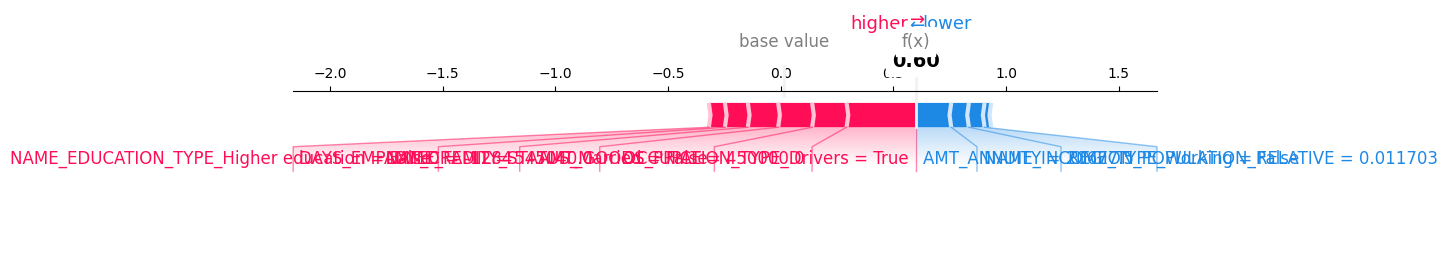

In [ ]:
# Explain a Decision
print("="*60)
print("Loan Decision Explanation")
print("="*60)

# Pick a random customer
idx = np.random.randint(0, len(X_test))
customer = X_test.iloc[[idx]]
customer_raw = df.iloc[X_test.index[idx]]

# Get prediction
prob_default = model_pipeline.predict_proba(customer)[0][1]
decision = "REJECTED" if prob_default > 0.5 else "APPROVED"
color = "red" if decision == "REJECTED" else "green"

print(f"Customer Profile:")
print(f"  - Income:      ${customer_raw['AMT_INCOME_TOTAL']:,.0f}")
print(f"  - Credit Amt:  ${customer_raw['AMT_CREDIT']:,.0f}")
print(f"  - Employment:  {customer_raw['DAYS_EMPLOYED']/-365:.1f} years")

print(f"\nAI Decision: {decision}")
print(f"Risk Score:  {prob_default:.1%} (Default Probability)")

# Explain WHY
print("\nWhy did the model make this decision?")
shap.initjs()
cust_trans = preprocessor.transform(customer)
shap_val = explainer.shap_values(cust_trans)

# Focus on top features to avoid label overlap in the force plot
top_idx = np.argsort(np.abs(shap_val[0]))[::-1][:10]
shap.force_plot(
    explainer.expected_value,
    shap_val[0][top_idx],
    customer.iloc[:, top_idx],
    feature_names=[training_columns[i] for i in top_idx],
    matplotlib=True,
    show=False
)
plt.gcf().set_size_inches(14, 3)
plt.tight_layout()
plt.show()


## 10. Save Model Locally

In [ ]:
# Save Models
joblib.dump(model_pipeline, 'best_model.joblib')
scaler = model_pipeline.named_steps['preprocessor'].transformers_[0][1]
joblib.dump(scaler, 'scaler.joblib')
print("✓ Models saved: best_model.joblib, scaler.joblib, training_columns.pkl")


✓ Models saved: best_model.joblib, scaler.joblib, training_columns.pkl


## 11. Upload Trained Model to Object Store

In [ ]:
print("Uploading models to MinIO...")
s3.upload_file('best_model.joblib', 'models', 'microloan/model.joblib')
s3.upload_file('best_model.joblib', 'models', 'microloan/best_model.joblib')  # legacy copy
s3.upload_file('scaler.joblib', 'models', 'microloan/scaler.joblib')
s3.upload_file('training_columns.pkl', 'models', 'microloan/training_columns.pkl')
print("✓ Upload complete! Ready for deployment.")


Uploading models to MinIO...
✓ Upload complete! Ready for deployment.


## 12. Generate LLM Training Data

In [ ]:
# Generate Rich Training Data for LLM (2000+ examples)
import random
import numpy as np

print("Generating rich training data for LLM fine-tuning...")
print("="*60)

llm_data = []

# Get SHAP explainer for feature importance
from sklearn.inspection import permutation_importance
model_clf = model_pipeline.named_steps['classifier']
preprocessor = model_pipeline.named_steps['preprocessor']

# More detailed templates with actual reasoning
approved_templates = [
    "Loan approved. Applicant shows strong financial stability with annual income of ${income:,}, credit amount ${credit:,} resulting in favorable debt-to-income ratio of {dti:.1f}%. {employment_detail} {education_detail} Risk score: {risk:.1f}%.",
    "Application accepted. Financial assessment indicates low default risk ({risk:.1f}%) based on income ${income:,}, manageable loan size ${credit:,}, and {employment_years:.1f} years of employment. {housing_detail}",
    "Approved for ${credit:,}. Strong indicators: {top_reason}. Income-to-debt ratio of {dti:.1f}% is well within acceptable range. {family_detail} Default probability: {risk:.1f}%.",
]

rejected_templates = [
    "Loan rejected. High default risk ({risk:.1f}%) identified. Income ${income:,} insufficient for loan amount ${credit:,}, resulting in concerning DTI of {dti:.1f}%. {employment_detail} {negative_factor}",
    "Application declined. Risk assessment shows: {top_reason}. Debt-to-income ratio of {dti:.1f}% exceeds safe lending thresholds. {credit_detail} Default probability: {risk:.1f}%.",
    "Rejected due to elevated risk ({risk:.1f}%). Income ${income:,} does not adequately support ${credit:,} loan. {employment_detail} {education_detail} Additional concern: {negative_factor}",
]

def get_employment_detail(days_employed):
    years = abs(days_employed) / 365
    if years > 10:
        return f"Established employment history of {years:.0f} years demonstrates stability."
    elif years > 5:
        return f"Solid {years:.0f}-year employment record."
    elif years > 1:
        return f"Recent employment ({years:.1f} years) raises minor concerns."
    else:
        return "Limited employment history increases risk."

def get_education_detail(row):
    if 'NAME_EDUCATION_TYPE_Higher_education' in row.index and row.get('NAME_EDUCATION_TYPE_Higher_education', 0) > 0:
        return "Higher education background positive indicator."
    elif 'NAME_EDUCATION_TYPE_Secondary_education' in row.index and row.get('NAME_EDUCATION_TYPE_Secondary_education', 0) > 0:
        return "Secondary education level noted."
    return "Education level considered in assessment."

def get_housing_detail(row):
    if 'NAME_HOUSING_TYPE_House_apartment' in row.index and row.get('NAME_HOUSING_TYPE_House_apartment', 0) > 0:
        return "Property ownership indicates financial stability."
    return "Housing situation assessed."

def get_family_detail(row):
    if 'CNT_FAM_MEMBERS' in row.index:
        members = int(row.get('CNT_FAM_MEMBERS', 1))
        if members > 3:
            return f"Family size ({members} members) considered in capacity assessment."
        return f"Small family unit ({members} members) noted."
    return ""

# Generate 2000 examples with rich details
for i in range(2000):
    idx = random.randint(0, len(X_test)-1)
    row = X_test.iloc[idx]
    row_df = X_test.iloc[[idx]]
    
    # Get prediction and probability
    pred = model_pipeline.predict(row_df)[0]
    prob = model_pipeline.predict_proba(row_df)[0]
    risk = prob[1] * 100  # Default probability
    
    # Extract features
    income = int(row.get('AMT_INCOME_TOTAL', 50000))
    credit = int(row.get('AMT_CREDIT', 10000))
    dti = (credit / income * 100) if income > 0 else 0
    days_employed = row.get('DAYS_EMPLOYED', -365)
    employment_years = abs(days_employed) / 365
    
    # Get contextual details
    employment_detail = get_employment_detail(days_employed)
    education_detail = get_education_detail(row)
    housing_detail = get_housing_detail(row)
    family_detail = get_family_detail(row)
    
    # Determine top reason (simplified)
    if pred == 0:  # Approved
        if dti < 30:
            top_reason = "excellent debt-to-income ratio"
        elif employment_years > 5:
            top_reason = "long-term employment stability"
        else:
            top_reason = "strong overall financial profile"
        
        template = random.choice(approved_templates)
        output_text = template.format(
            income=income,
            credit=credit,
            dti=dti,
            risk=risk,
            employment_years=employment_years,
            employment_detail=employment_detail,
            education_detail=education_detail,
            housing_detail=housing_detail,
            family_detail=family_detail,
            top_reason=top_reason
        )
    else:  # Rejected
        if dti > 50:
            top_reason = "debt-to-income ratio exceeds 50%"
            negative_factor = f"monthly payments would consume {dti:.0f}% of income"
        elif income < 30000:
            top_reason = "income below minimum threshold"
            negative_factor = "insufficient repayment capacity"
        else:
            top_reason = "multiple risk factors identified"
            negative_factor = "credit history and capacity concerns"
        
        credit_detail = f"Loan amount ${credit:,} deemed too high for income level."
        
        template = random.choice(rejected_templates)
        output_text = template.format(
            income=income,
            credit=credit,
            dti=dti,
            risk=risk,
            employment_years=employment_years,
            employment_detail=employment_detail,
            education_detail=education_detail,
            top_reason=top_reason,
            negative_factor=negative_factor,
            credit_detail=credit_detail
        )
    
    # Create input prompt
    input_text = f"Explain loan decision: credit_score={(1-risk/100)*1000:.0f}, income={income}, dti={dti:.1f}, loan_amount={credit}, decision={'approved' if pred==0 else 'rejected'}"
    
    llm_data.append({"input": input_text, "output": output_text})

# Save to JSON
with open('feature_explanations_dataset.json', 'w') as f:
    json.dump(llm_data, f, indent=2)

print(f"✓ Generated {len(llm_data)} rich training examples")
print(f"  - Approved: {sum(1 for d in llm_data if 'approved' in d['input'])}")
print(f"  - Rejected: {sum(1 for d in llm_data if 'rejected' in d['input'])}")
print("\nSample approved:")
approved_sample = [d for d in llm_data if 'approved' in d['input']][0]
print(f"Input:  {approved_sample['input']}")
print(f"Output: {approved_sample['output'][:200]}...")
print("\nSample rejected:")
rejected_sample = [d for d in llm_data if 'rejected' in d['input']][0]
print(f"Input:  {rejected_sample['input']}")
print(f"Output: {rejected_sample['output'][:200]}...")
